# Imports

In [1]:
# ------------------------------------------------------------------------------
# Suppress Warnings
# ------------------------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# Data Science Libraries
# ------------------------------------------------------------------------------
import numpy as np
import pandas as pd
import xarray as xr  # Multi-dimensional arrays and datasets

# ------------------------------------------------------------------------------
# Geospatial Data Handling
# ------------------------------------------------------------------------------
import rioxarray as rxr          # Geospatial raster data handling
import geopandas as gpd          # Geospatial data analysis

# Raster operations with rasterio
import rasterio
from rasterio import windows, features, warp
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds

# ------------------------------------------------------------------------------
# Visualization
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------------------
# Image Processing
# ------------------------------------------------------------------------------
from PIL import Image

# ------------------------------------------------------------------------------
# Coordinate Transformations
# ------------------------------------------------------------------------------
from pyproj import Proj, Transformer, CRS

# ------------------------------------------------------------------------------
# Feature Engineering & Model Selection
# ------------------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

# ------------------------------------------------------------------------------
# Machine Learning & Metrics
# ------------------------------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

# ------------------------------------------------------------------------------
# Gaussian Process Regression
# ------------------------------------------------------------------------------
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

# ------------------------------------------------------------------------------
# Planetary Computer Tools
# ------------------------------------------------------------------------------
import pystac_client
import planetary_computer as pc
from pystac.extensions.eo import EOExtension as eo

# ------------------------------------------------------------------------------
# Other Utilities
# ------------------------------------------------------------------------------
import os
from tqdm import tqdm
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon, Point
import ast


# Band Data

In [2]:
ground_df = pd.read_csv("Training_data_uhi_index_UHI2025-v2.csv")
ground_df.head()

,Longitude,Latitude,datetime,UHI Index
0,-73.909167,40.813107,24-07-2021 15:53,1.030289
1,-73.909187,40.813045,24-07-2021 15:53,1.030289
2,-73.909215,40.812978,24-07-2021 15:53,1.023798
3,-73.909242,40.812908,24-07-2021 15:53,1.023798
4,-73.909257,40.812845,24-07-2021 15:53,1.021634


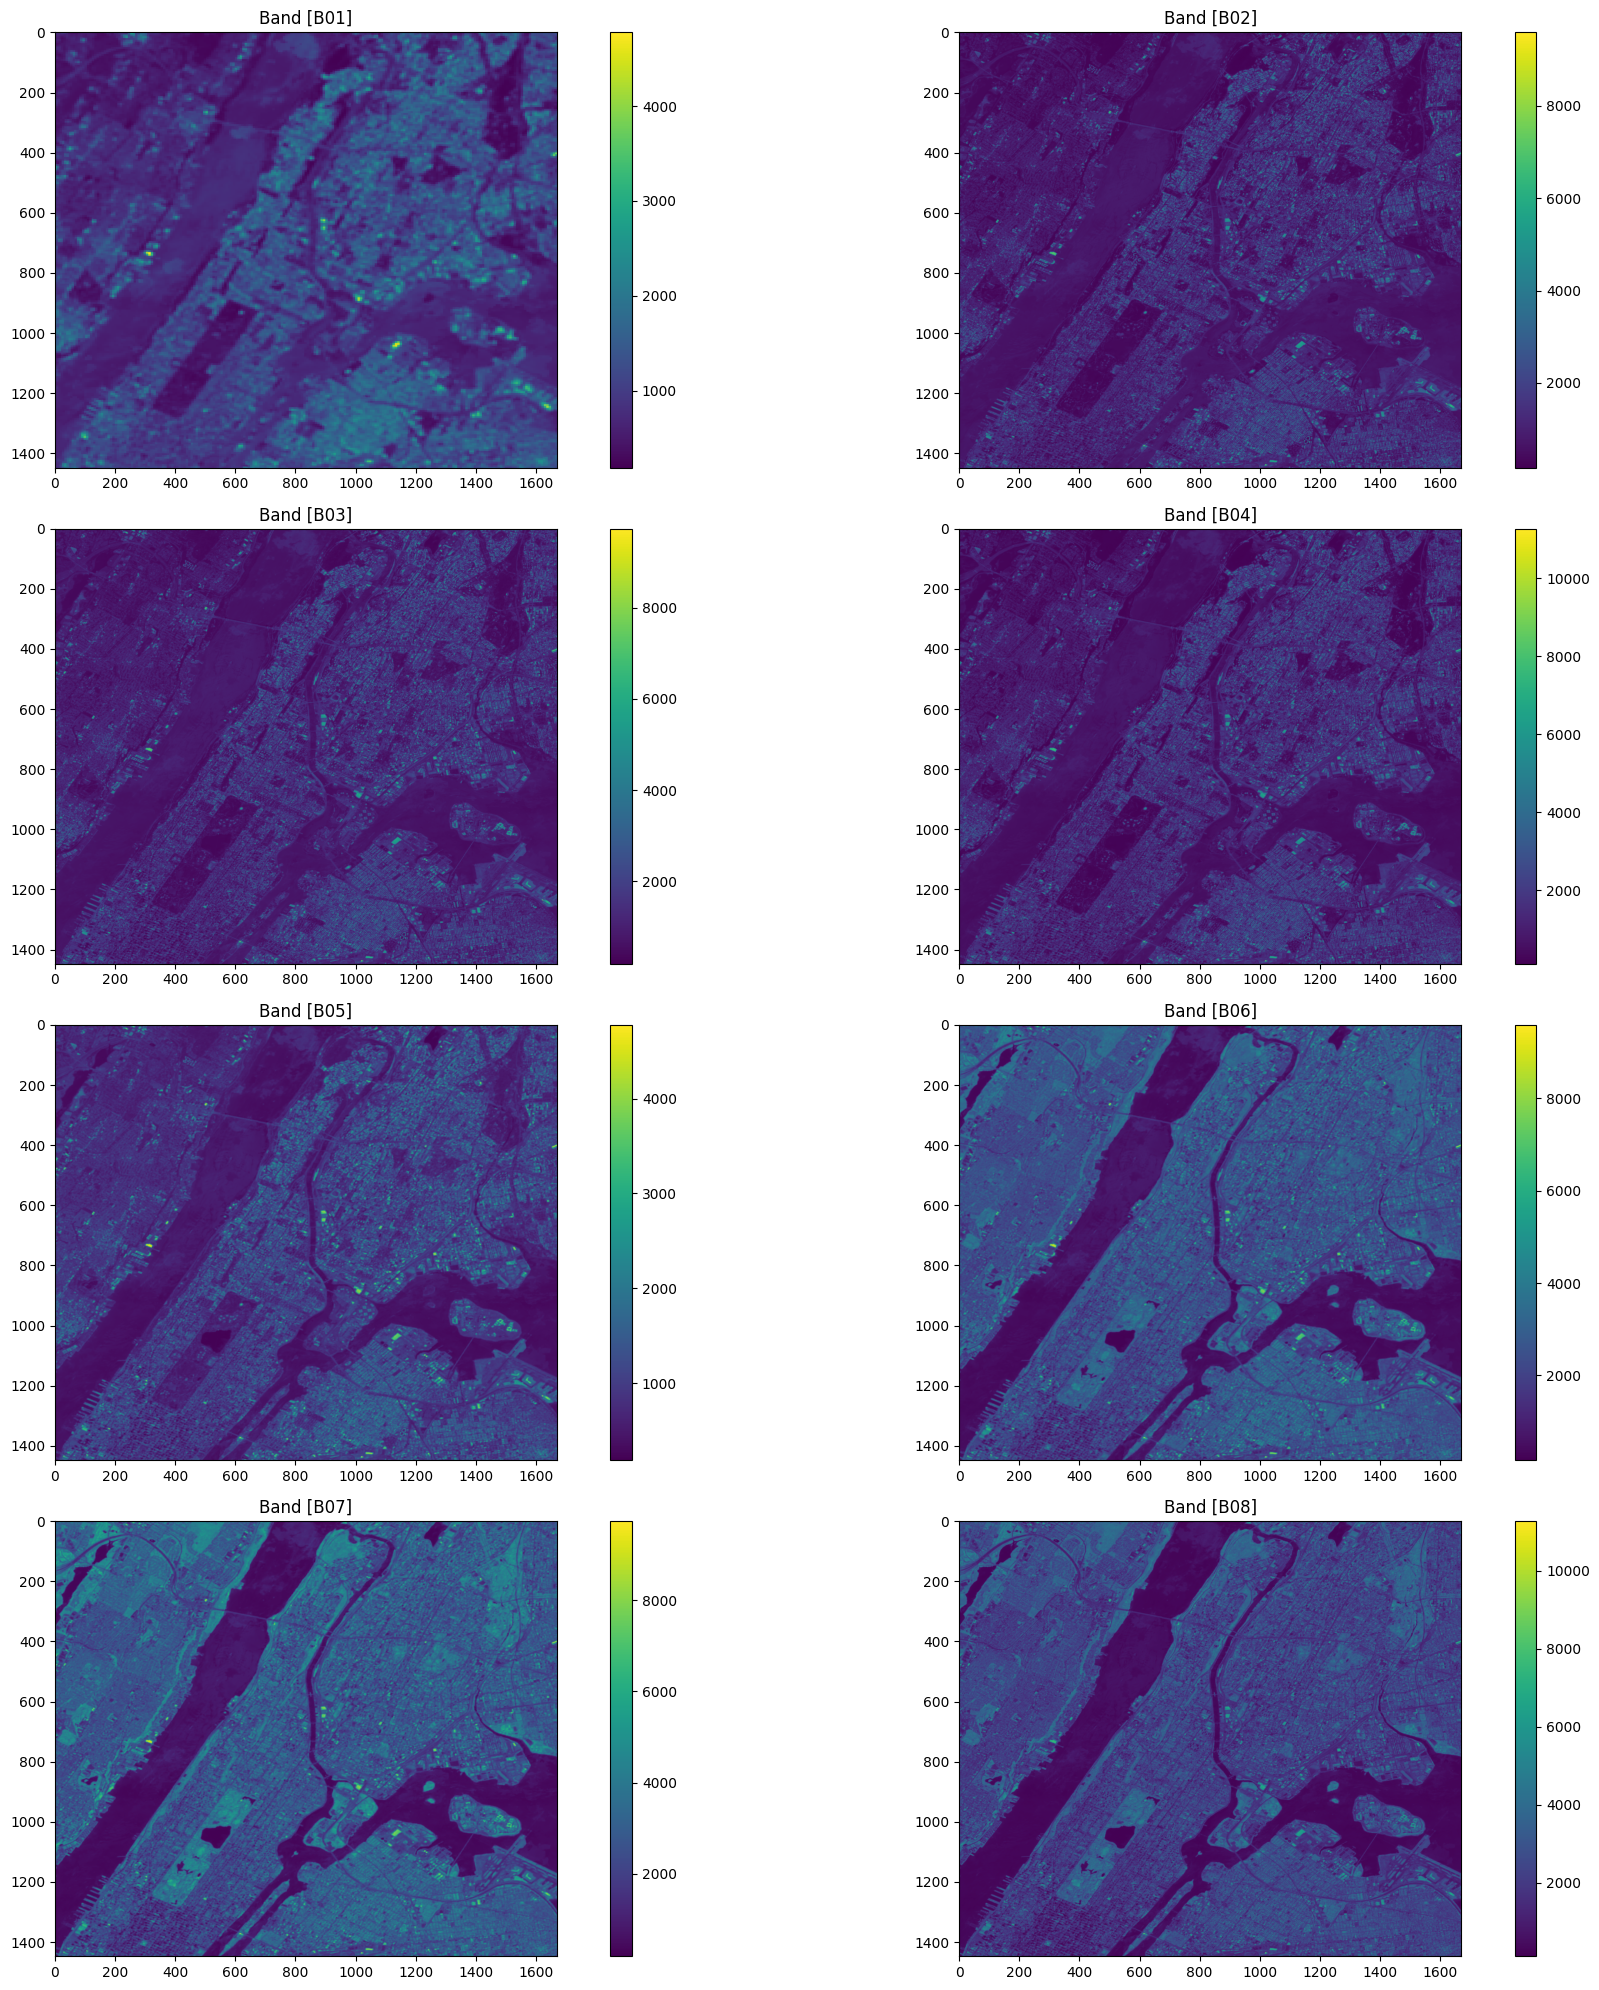

In [3]:

# Open the GeoTIFF file
tiff_path = "S2_sample.tiff"

# Read the bands from the GeoTIFF file
with rasterio.open(tiff_path) as src1:
    band1 = src1.read(1)  # Band [B01]
    band2 = src1.read(2)  # Band [B02]
    band3 = src1.read(3)  # Band [B03]
    band4 = src1.read(4)  # Band [B04]
    band5 = src1.read(5)  # Band [B05]
    band6 = src1.read(6)  # Band [B06]
    band7 = src1.read(7)  # Band [B07]
    band8 = src1.read(8)  # Band [B08]
    band9 = src1.read(9)  # Band [B8A]
    band10 = src1.read(10)  # Band [B11]
    band11 = src1.read(11)  # Band [B12]

# Plot the bands in a 2x2 grid
fig, axes = plt.subplots(4, 2, figsize=(20, 20))

# Flatten the axes for easier indexing
axes = axes.flatten()
    
# Plot the first band (B01)
im1 = axes[0].imshow(band1, cmap='viridis')
axes[0].set_title('Band [B01]')
fig.colorbar(im1, ax=axes[0])

# Plot the second band (B02)
im2 = axes[1].imshow(band2, cmap='viridis')
axes[1].set_title('Band [B02]')
fig.colorbar(im2, ax=axes[1])

# Plot the third band (B04)
im3 = axes[2].imshow(band3, cmap='viridis')                 
axes[2].set_title('Band [B03]')
fig.colorbar(im3, ax=axes[2])

# Plot the fourth band (B04)
im4 = axes[3].imshow(band4, cmap='viridis')
axes[3].set_title('Band [B04]')
fig.colorbar(im4, ax=axes[3])

# Plot B05
im5 = axes[4].imshow(band5, cmap='viridis')
axes[4].set_title('Band [B05]')
fig.colorbar(im1, ax=axes[4])

# Plot B06
im6 = axes[5].imshow(band6, cmap='viridis')
axes[5].set_title('Band [B06]')
fig.colorbar(im2, ax=axes[5])

# Plot B07
im7 = axes[6].imshow(band7, cmap='viridis')                 
axes[6].set_title('Band [B07]')
fig.colorbar(im3, ax=axes[6])

# Plot B08
im8 = axes[7].imshow(band8, cmap='viridis')
axes[7].set_title('Band [B08]')
fig.colorbar(im4, ax=axes[7])

plt.tight_layout()
plt.show()

### Band Data No Buffer

In [4]:
def map_satellite_data(tiff_path, csv_path):
    
    # Load the GeoTIFF data
    data = rxr.open_rasterio(tiff_path)
    tiff_crs = data.rio.crs

    # Read the Excel file using pandas
    df = pd.read_csv(csv_path)
    latitudes = df['Latitude'].values
    longitudes = df['Longitude'].values

    # 3. Convert lat/long to the GeoTIFF's CRS
    # Create a Proj object for EPSG:4326 (WGS84 - lat/long) and the GeoTIFF's CRS
    proj_wgs84 = Proj(init='epsg:4326')  # EPSG:4326 is the common lat/long CRS
    proj_tiff = Proj(tiff_crs)
    
    # Create a transformer object
    transformer = Transformer.from_proj(proj_wgs84, proj_tiff)

    B01_values = []
    B02_values = []
    B03_values = []
    B04_values = []
    B05_values = []
    B06_values = []
    B07_values = []
    B08_values = []
    B8A_values = []
    B11_values = []
    B12_values = []

# Iterate over the latitudes and longitudes, and extract the corresponding band values
    for lat, lon in tqdm(zip(latitudes, longitudes), total=len(latitudes), desc="Mapping values"):
    # Assuming the correct dimensions are 'y' and 'x' (replace these with actual names from data.coords)
    
        B01_value = data.sel(x=lon, y=lat,  band=1, method="nearest").values
        B01_values.append(B01_value)
    
        B02_value = data.sel(x=lon, y=lat, band=2, method="nearest").values
        B02_values.append(B02_value)
        
        B03_value = data.sel(x=lon, y=lat, band=3, method="nearest").values
        B03_values.append(B03_value)
    
        B04_value = data.sel(x=lon, y=lat, band=4, method="nearest").values
        B04_values.append(B04_value)
                
        B05_value = data.sel(x=lon, y=lat,  band=5, method="nearest").values
        B05_values.append(B05_value)
    
        B06_value = data.sel(x=lon, y=lat, band=6, method="nearest").values
        B06_values.append(B06_value)
        
        B07_value = data.sel(x=lon, y=lat, band=7, method="nearest").values
        B07_values.append(B07_value)
    
        B08_value = data.sel(x=lon, y=lat, band=8, method="nearest").values
        B08_values.append(B08_value)
        
        B8A_value = data.sel(x=lon, y=lat,  band=9, method="nearest").values
        B8A_values.append(B8A_value)
    
        B11_value = data.sel(x=lon, y=lat, band=10, method="nearest").values
        B11_values.append(B11_value)
        
        B12_value = data.sel(x=lon, y=lat, band=11, method="nearest").values
        B12_values.append(B12_value)
    
    # Create a DataFrame with the band values
    # Create a DataFrame to store the band values
    
    # df = pd.DataFrame()
    df['B01'] = B01_values
    df['B02'] = B02_values
    df['B03'] = B03_values
    df['B04'] = B04_values
    df['B05'] = B05_values
    df['B06'] = B06_values
    df['B07'] = B07_values
    df['B08'] = B08_values
    df['B8A'] = B8A_values
    df['B11'] = B11_values
    df['B12'] = B12_values

    
    
    return df


### Band Data With Buffer

In [5]:
def map_satellite_data_with_buffer(tiff_path, csv_path, buffer_distance=50):
    """
    Reads a GeoTIFF and a CSV file containing Latitude and Longitude.
    For each location, converts to the TIFF's CRS (ensuring it is projected) 
    and extracts the mean pixel values within a buffer of the specified 
    distance (in meters) for each band.
    """
    # Load the GeoTIFF data
    data = rxr.open_rasterio(tiff_path)
    
    # Check if CRS is projected (units in meters); if not, reproject
    if data.rio.crs.is_geographic:
        # You need to choose an appropriate projected CRS for your region.
        # For example, if your data is in Europe, you might use EPSG:3035, or for UTM zones, something like EPSG:32633.
        projected_crs = "EPSG:32633"  # Update this based on your region
        data = data.rio.reproject(projected_crs)
    
    tiff_crs = data.rio.crs

    # Read the CSV file using pandas
    df = pd.read_csv(csv_path)
    latitudes = df['Latitude'].values
    longitudes = df['Longitude'].values

    # Convert lat/long to the GeoTIFF's CRS (which is now projected and in meters)
    proj_wgs84 = Proj("epsg:4326")
    proj_tiff = Proj(tiff_crs)
    transformer = Transformer.from_proj(proj_wgs84, proj_tiff, always_xy=True)

    # Initialize lists for band values
    bands = {
        'B01': [], 'B02': [], 'B03': [], 'B04': [], 'B05': [],
        'B06': [], 'B07': [], 'B08': [], 'B8A': [], 'B11': [], 'B12': []
    }
    
    # Iterate over each location
    for lat, lon in tqdm(zip(latitudes, longitudes), total=len(latitudes), desc="Mapping values"):
        # Transform the point coordinates from lat/lon to the raster's CRS (x, y in meters)
        x_center, y_center = transformer.transform(lon, lat)
        
        # Define the buffer window in meters
        x_min, x_max = x_center - buffer_distance, x_center + buffer_distance
        y_min, y_max = y_center - buffer_distance, y_center + buffer_distance
        
        # Adjust y slicing if the raster's y coordinates are descending:
        if data.coords['y'][0] > data.coords['y'][-1]:
            y_slice = slice(y_max, y_min)
        else:
            y_slice = slice(y_min, y_max)
        
        # Loop over each band (assuming bands are stored as band numbers 1 through 11)
        for i, band_key in enumerate(bands.keys(), start=1):
            # Extract the window and compute the mean (ignoring NaNs)
            band_value = data.sel(x=slice(x_min, x_max), y=y_slice, band=i).mean().values
            bands[band_key].append(band_value)
    
    # Create a DataFrame from the extracted band values
    output_df = pd.DataFrame(bands)
    return output_df

# Example usage:
# df_extracted = map_satellite_data_with_buffer('S2_sample.tiff', 'Training_data_uhi_index_UHI2025-v2.csv')


In [6]:
band_data = map_satellite_data('S2_sample.tiff', 'Training_data_uhi_index_UHI2025-v2.csv')

Mapping values: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 11229/11229 [00:38<00:00, 288.43it/s]


In [7]:
band_data.head()

,Longitude,Latitude,datetime,UHI Index,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,841.5,1053.0,1155.0,1206.0,1481.5,1660.5,1721.0,1832.0,1709.0,1792.0,1495.5
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,841.5,1053.0,1155.0,1206.0,1481.5,1660.5,1721.0,1832.0,1709.0,1792.0,1495.5
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,841.5,646.0,823.0,777.0,1130.5,1883.0,2117.5,2241.0,2251.0,1548.0,1135.0
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,841.5,625.0,766.0,741.5,1130.5,1883.0,2117.5,2200.0,2251.0,1548.0,1135.0
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,841.5,659.5,763.0,708.5,1077.5,1783.0,2042.0,2161.0,2186.0,1617.5,1207.5


# Building Data

In [8]:
def parse_kml_to_df(kml_file):
    # Parse the KML file into an ElementTree object
    tree = ET.parse(kml_file)
    root = tree.getroot()
    
    # Define the namespace mapping for KML elements
    ns = {'kml': 'http://www.opengis.net/kml/2.2'}
    
    data = []
    
    # Find all Placemark elements in the KML
    for placemark in root.findall('.//kml:Placemark', ns):
        row = {}
        
        # Extract the ExtendedData / SchemaData SimpleData values
        schema_data = placemark.find('.//kml:SchemaData', ns)
        if schema_data is not None:
            for simpledata in schema_data.findall('kml:SimpleData', ns):
                key = simpledata.attrib.get('name')
                value = simpledata.text
                row[key] = value
        
        # Extract the coordinates from the first <coordinates> element in the Placemark
        coordinates_elem = placemark.find('.//kml:coordinates', ns)
        if coordinates_elem is not None:
            row['coordinates'] = coordinates_elem.text.strip()
        else:
            row['coordinates'] = None
        
        data.append(row)
    
    # Create and return a pandas DataFrame from the extracted data

    df = pd.DataFrame(data)
    
    def process_coordinates(coord_string):
        coord_pairs = coord_string.split()
        return [tuple(map(float, coord.split(','))) for coord in coord_pairs]

    df['coordinates'] = df['coordinates'].apply(process_coordinates)

    return df

In [9]:
def get_building_footprint_area_data(kml_file, csv_path):

    ground_df = pd.read_csv(csv_path)
    
    buildings_df = parse_kml_to_df(kml_file)
    buildings_df = buildings_df.drop(columns = ['path', 'id', 'tessellate', 'extrude', 'visibility'])

    # buildings_df['coordinates'] = buildings_df['coordinates'].apply(ast.literal_eval)
    buildings_df['geometry'] = buildings_df['coordinates'].apply(Polygon)

    gdf_buildings = gpd.GeoDataFrame(buildings_df, geometry='geometry', crs="EPSG:4326")

    gdf_ground = gpd.GeoDataFrame(
        ground_df,
        geometry=gpd.points_from_xy(ground_df['Longitude'], ground_df['Latitude']),
        crs="EPSG:4326"
    )


    gdf_buildings = gdf_buildings.to_crs("EPSG:32618")
    gdf_ground = gdf_ground.to_crs("EPSG:32618")

    def calculate_building_area(point, buildings, buffer_size):
        buffer = point.buffer(buffer_size)
        intersecting_buildings = buildings[buildings.intersects(buffer)]
        total_area = intersecting_buildings.geometry.intersection(buffer).area.sum()
        return total_area

    gdf_ground['building_area_25']  = gdf_ground.geometry.apply(lambda pt: calculate_building_area(pt, gdf_buildings, 25))
    gdf_ground['building_area_50']  = gdf_ground.geometry.apply(lambda pt: calculate_building_area(pt, gdf_buildings, 50))
    gdf_ground['building_area_100'] = gdf_ground.geometry.apply(lambda pt: calculate_building_area(pt, gdf_buildings, 100))

    # Optionally, convert back to a pandas DataFrame if you don't need the geometry column:
    result_df = pd.DataFrame(gdf_ground.drop(columns='geometry'))

    return(result_df)

In [10]:
building_data = get_building_footprint_area_data('Building_Footprint.kml', 'Training_data_uhi_index_UHI2025-v2.csv')

In [11]:
building_data.head()

,Longitude,Latitude,datetime,UHI Index,building_area_25,building_area_50,building_area_100
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,183.978594,1597.323120,11046.690248
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,266.930647,1729.473614,10814.226850
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,321.122238,1951.435804,10525.136565
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,343.873068,2287.039351,10446.113598
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,382.402733,2652.734741,10479.891453


# Weather Data

In [12]:
def get_weather_data(loc_df: pd.DataFrame) -> pd.DataFrame:
    
    # Read in weather data from Excel
    manhattan_weather_data = pd.read_excel(io='NY_Mesonet_Weather.xlsx',sheet_name='Manhattan')
    bronx_weather_data = pd.read_excel(io='NY_Mesonet_Weather.xlsx',sheet_name='Bronx')

    # Split loc_df into "Bronx" and "Manhattan based on Lat/Long cutoff"
    loc_df['Area'] = np.where(loc_df['Latitude'] > (-8/3) * loc_df['Longitude'] - 156.343,'Bronx','Manhattan')


    # Copy df into bronx and manhattan dfs
    manhattan_df = loc_df.loc[loc_df['Area'] == 'Manhattan'].copy()
    bronx_df = loc_df.loc[loc_df['Area'] == 'Bronx'].copy()

    bronx_final = match_datetime(bronx_df, bronx_weather_data)
    man_final = match_datetime(manhattan_df, manhattan_weather_data)

    final_weather = pd.concat([bronx_final,man_final])

    final_weather['datetime'] = final_weather['datetime'].dt.strftime('%d-%m-%Y %H:%M')

    final_weather.reset_index(drop=True,inplace=True)

    return final_weather

In [13]:
def match_datetime(df: pd.DataFrame, weather: pd.DataFrame) -> pd.DataFrame:
    '''
    Convert datetime column to pd.datetime in the correct format and match closest in time weather observation to each time in df.
    '''
    df['datetime'] = pd.to_datetime(df['datetime'], format='%d-%m-%Y %H:%M')
    df['datetime'] = df['datetime'].dt.strftime('%Y-%m-%d %H:%M')
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.sort_values(by='datetime')

    weather.columns = ['datetime','airtemp','relative humidity', 'avg wind speed', 'wind direction', 'solar flux']
    weather['datetime'] = weather['datetime'].str.replace('EDT','')
    weather['datetime'] = pd.to_datetime(weather['datetime'])

    merged_final = pd.merge_asof(df, weather, on='datetime', direction='nearest')

    return merged_final
    

In [14]:
weather_data = get_weather_data(ground_df)

In [15]:
weather_data.head()

,Longitude,Latitude,datetime,UHI Index,Area,airtemp,relative humidity,avg wind speed,wind direction,solar flux
0,-73.909753,40.803593,24-07-2021 15:01,0.998554,Bronx,28.0,40.3,3.0,75,725
1,-73.910567,40.803945,24-07-2021 15:01,1.009373,Bronx,28.0,40.3,3.0,75,725
2,-73.910465,40.803903,24-07-2021 15:01,1.007209,Bronx,28.0,40.3,3.0,75,725
3,-73.910367,40.803858,24-07-2021 15:01,1.007209,Bronx,28.0,40.3,3.0,75,725
4,-73.910268,40.803817,24-07-2021 15:01,1.000718,Bronx,28.0,40.3,3.0,75,725


# Energy Data

In [16]:
def get_building_energy(energy_csv, training_csv):
    import pandas as pd
    import numpy as np
    import geopandas as gpd
    from shapely.geometry import Point
    
    energy = pd.read_csv(energy_csv)

    selected_columns = [
    "Latitude",
    "Longitude",
    "Weather Normalized Site EUI (kBtu/ft²)",
    "Weather Normalized Site Energy Use (kBtu)",
    "Electricity Use - Grid Purchase (kWh)",
    "Natural Gas Use (kBtu)",
    "ENERGY STAR Score"
    ]

    available_columns = [col for col in selected_columns if col in energy.columns]
    df_selected = energy[available_columns]
    df_selected.replace('Not Available', np.nan, inplace=True)
    df_selected.dropna(inplace=True)
    df_selected = df_selected.apply(pd.to_numeric, errors='coerce')

    df1 = df_selected
    df2 = pd.read_csv(training_csv)

    # Example dataframes (replace with your actual data)
    # df1: Contains energy use metrics and coordinates
    # df2: Contains only coordinates
    # Assume columns 'longitude' and 'latitude' in both dataframes

    # Create GeoDataFrames from df1 and df2
    gdf1 = gpd.GeoDataFrame(
        df1,
        geometry=gpd.points_from_xy(df1.Longitude, df1.Latitude),
        crs="EPSG:4326"  # Assuming original coordinates are in WGS84
    )

    gdf2 = gpd.GeoDataFrame(
        df2,
        geometry=gpd.points_from_xy(df2.Longitude, df2.Latitude),
        crs="EPSG:4326"
    )

    # Project to a CRS with meters as units (e.g., EPSG:3857 or a local UTM)
    gdf1 = gdf1.to_crs(epsg=3857)
    gdf2 = gdf2.to_crs(epsg=3857)

    # Create a buffer of 50 meters around each point in gdf2
    gdf2['buffer'] = gdf2.geometry.buffer(200)

    # It is often useful to work with the buffer as the geometry for spatial join
    gdf2_buffer = gdf2.copy()
    gdf2_buffer.set_geometry('buffer', inplace=True)

    # Perform a spatial join: find all gdf1 points within each buffer from gdf2
    # The 'op' parameter has been renamed to 'predicate' in recent versions of GeoPandas.
    joined = gpd.sjoin(gdf1, gdf2_buffer, predicate='within')

    # Now, joined contains df1 rows with an index reference (index_right) to gdf2_buffer.
    # Group by the df2 index (index_right) and compute the mean for each energy metric column.
    # Replace 'Natural Gas Use (kBtu)' with your actual energy use metric columns as needed.
    energy_columns = ['Weather Normalized Site EUI (kBtu/ft²)',
        'Weather Normalized Site Energy Use (kBtu)',
        'Electricity Use - Grid Purchase (kWh)', 'Natural Gas Use (kBtu)',
        'ENERGY STAR Score']  # add other metric columns here

    aggregated = joined.groupby('index_right')[energy_columns].mean().reset_index()

    result = gdf2.merge(aggregated, left_index=True, right_on='index_right', how='left')

    result = result.drop(columns=['buffer'])

    result = result.to_crs(epsg=4326)
    result = result.drop(columns=['geometry'])

    result.set_index("index_right", inplace=True)
    result.fillna(0, inplace=True)
    result.reset_index(drop=True,inplace=True)
    return(result)

In [17]:
energy_path = 'Energy_and_Water_Data_Disclosure_for_Local_Law_84_2022__Data_for_Calendar_Year_2021__20250304.csv'
ground_path = 'Training_data_uhi_index_UHI2025-v2.csv'
energy_data = get_building_energy(energy_path, ground_path)

In [18]:
energy_data.head()

,Longitude,Latitude,datetime,UHI Index,Weather Normalized Site EUI (kBtu/ft²),Weather Normalized Site Energy Use (kBtu),Electricity Use - Grid Purchase (kWh),Natural Gas Use (kBtu),ENERGY STAR Score
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,103.6,7.428419e+06,465421.633333,4012489.3,39.0
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,103.6,7.428419e+06,465421.633333,4012489.3,39.0
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,103.6,7.428419e+06,465421.633333,4012489.3,39.0
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,103.6,7.428419e+06,465421.633333,4012489.3,39.0
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,103.6,7.428419e+06,465421.633333,4012489.3,39.0


# Merge All Data

In [19]:
merged_df = pd.merge(weather_data, building_data, on=['Latitude', 'Longitude','datetime','UHI Index'], how='outer')
merged_df = pd.merge(merged_df, band_data, on=['Latitude', 'Longitude','datetime','UHI Index'], how='outer')
merged_df = pd.merge(merged_df, energy_data, on=['Latitude', 'Longitude','datetime','UHI Index'], how='outer')

# Shuffle data to remove ordering bias
merged_df = merged_df.sample(frac=1, random_state=42).reset_index(drop=True)
merged_df.head()

,Longitude,Latitude,datetime,UHI Index,Area,airtemp,relative humidity,avg wind speed,wind direction,solar flux,...,B07,B08,B8A,B11,B12,Weather Normalized Site EUI (kBtu/ft²),Weather Normalized Site Energy Use (kBtu),Electricity Use - Grid Purchase (kWh),Natural Gas Use (kBtu),ENERGY STAR Score
0,-73.953428,40.812315,24-07-2021 15:51,1.011056,Manhattan,26.6,48.3,3.5,184,181,...,2814.0,3654.0,2774.5,3128.5,2889.0,88.930000,4.019089e+06,4.353812e+05,2.297991e+06,56.200000
1,-73.927362,40.835453,24-07-2021 15:40,0.992424,Bronx,26.9,48.3,3.0,166,371,...,2305.5,1730.0,2259.0,2841.5,2701.5,107.880000,7.758938e+06,3.929775e+05,5.542057e+06,46.400000
2,-73.969710,40.790145,24-07-2021 15:28,0.971147,Manhattan,27.3,45.4,3.8,202,349,...,1570.0,1501.0,1816.0,1950.5,1696.0,68.900000,1.109130e+07,1.251430e+06,4.204287e+06,75.181818
3,-73.919355,40.804170,24-07-2021 15:05,1.024880,Bronx,28.1,40.2,1.7,92,558,...,2144.0,1592.0,2093.5,2107.5,1908.0,68.850000,3.193282e+06,3.113264e+05,1.920306e+06,50.500000
4,-73.952470,40.810912,24-07-2021 15:53,1.024279,Manhattan,26.8,46.7,3.4,196,605,...,1976.0,2211.0,1955.5,2384.5,2302.0,111.263636,5.523921e+06,8.979704e+05,2.208624e+06,47.909091


In [55]:
merged_df.to_csv('save_train_data_unscaled.csv',index=False)

# Data Preprocessing

In [20]:
X_train = merged_df.drop(columns=['Longitude', 'Latitude', 'datetime', 'UHI Index'])
# One-hot encode the categorical 'Area' column (drop_first avoids dummy variable trap)
X_train = pd.get_dummies(X_train, columns=['Area'], drop_first=True)

# Identify numeric feature columns (exclude boolean columns)
input_features = X_train.select_dtypes(exclude=['boolean']).columns

# Initialize and fit the scaler on training numeric features
scaler = StandardScaler()
X_train[input_features] = scaler.fit_transform(X_train[input_features])

# Define the target variable
y_train = merged_df['UHI Index']

# PCA on Band data
# bands = band_data.drop(['Longitude', 'Latitude', 'datetime', 'UHI Index'],axis=1).columns

# X_train_pca = X_train[bands]

# n_components = 6 
# pca = PCA(n_components=n_components)
# X_train_pca = pca.fit_transform(X_train_pca)

# print("Explained Variance Ratio:", sum(pca.explained_variance_ratio_))

# pc_names = []
# for i in range(n_components):
#     pc_names.append('PC'+str(i+1))

# X_train_pca_df = pd.DataFrame(data=X_train_pca, columns=pc_names)

# X_train = pd.concat([X_train.drop(columns=bands),X_train_pca_df],axis=1)

In [21]:
X_train.columns

Index(['airtemp', 'relative humidity', 'avg wind speed', 'wind direction',
       'solar flux', 'building_area_25', 'building_area_50',
       'building_area_100', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07',
       'B08', 'B8A', 'B11', 'B12', 'Weather Normalized Site EUI (kBtu/ft²)',
       'Weather Normalized Site Energy Use (kBtu)',
       'Electricity Use - Grid Purchase (kWh)', 'Natural Gas Use (kBtu)',
       'ENERGY STAR Score', 'Area_Manhattan'],
      dtype='object')

In [22]:
y_train.head()

0    1.011056
1    0.992424
2    0.971147
3    1.024880
4    1.024279
Name: UHI Index, dtype: float64

Save data to CSV just in case.

In [26]:
saved_train_data = pd.concat([X_train, y_train], axis=1)
saved_train_data.to_csv('saved_train_data.csv',index=False)

# Model Training

In [23]:
import joblib
best_rf = joblib.load('best_random_forest.pkl')

Training #1 took 38 minutes and 57 seconds: 
https://docs.google.com/document/d/1MZXIpV8ZmRL0rYKyD3R_qXoX1YBjPo6D1bLrl17uPMc/edit?tab=t.0

Training #2

In [117]:
# Define the parameter grid
param_grid = {
    'n_estimators': [250,500,1000],
    'max_depth': [None,100,200],
    'max_features': ['sqrt',X_train.shape[1] - 1]
}

# Initialize the model
rf = RandomForestRegressor()

kf = KFold(n_splits=5, shuffle=True, random_state=123)

# Setup GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=kf, n_jobs=-1, scoring='r2',verbose=1)

# Fit to training data
grid_search.fit(X_train, y_train)

# Output the best parameters
print("Best Hyperparameters:", grid_search.best_params_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Hyperparameters: {'max_depth': None, 'max_features': 24, 'n_estimators': 1000}


In [26]:
print('Train R^2:', r2_score(best_rf.predict(X_train),y_train))
# print('Test R^2:',max(grid_search.cv_results_['mean_test_score']))

Train R^2: 0.990035570079345


# Model Metrics

In [120]:
results_df = pd.DataFrame(grid_search.cv_results_)

# Expand the "params" dictionary into separate columns
params_df = results_df['params'].apply(pd.Series)

# Concatenate these new columns with the original results DataFrame
results_expanded = pd.concat([results_df.drop(columns=['params']), params_df], axis=1)

# Now, to get the top 5 combinations based on rank_test_score:
top = results_expanded.nsmallest(10, 'rank_test_score')

# Display the top 5, including individual parameter columns
top[['rank_test_score', 'mean_test_score', 'std_test_score'] + list(params_df.columns)]

,rank_test_score,mean_test_score,std_test_score,max_depth,max_features,n_estimators
5,1,0.913254,0.006947,NaN,24.0,1000.0
16,2,0.913227,0.006494,200.0,24,500.0
10,3,0.913155,0.006540,100.0,24,500.0
17,4,0.913121,0.006907,200.0,24,1000.0
11,5,0.913089,0.006488,100.0,24,1000.0
15,6,0.912992,0.007037,200.0,24,250.0
3,7,0.912853,0.006356,NaN,24.0,250.0
4,8,0.912790,0.007364,NaN,24.0,500.0
9,9,0.912077,0.006041,100.0,24,250.0
8,10,0.902531,0.007059,100.0,sqrt,1000.0


Save model locally

In [287]:
import joblib

# joblib.dump(best_rf, 'best_random_forest.pkl')
# Example Usuage: 
# loaded_model = joblib.load('best_random_forest.pkl')

['best_random_forest.pkl']

In [28]:
import joblib
best_rf = joblib.load('best_random_forest.pkl')

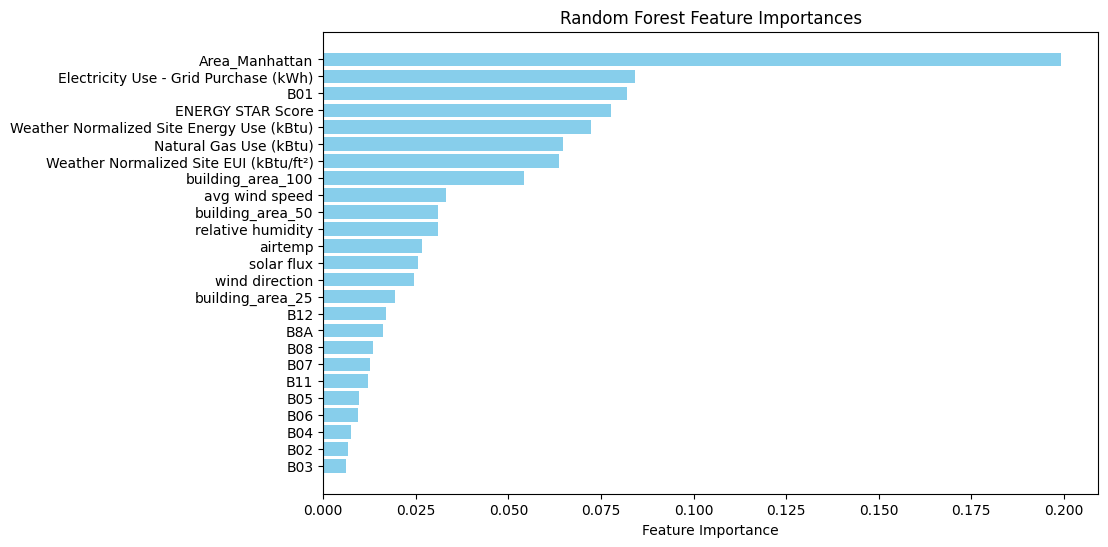

In [27]:
importances = best_rf.feature_importances_
features = X_train.columns

# Create a DataFrame for easier plotting and sorting
feat_imp = pd.DataFrame({'feature': features, 'importance': importances})
feat_imp = feat_imp.sort_values(by='importance', ascending=False)

# Plot the feature importances as a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'], color='skyblue')
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

# Validation Features

In [29]:
validation_df = pd.read_csv("Submission_template_UHI2025-v2.csv")
validation_df.head()

,Longitude,Latitude,UHI Index
0,-73.971665,40.788763,NaN
1,-73.971928,40.788875,NaN
2,-73.967080,40.789080,NaN
3,-73.972550,40.789082,NaN
4,-73.969697,40.787953,NaN


# Validation Band Data

In [30]:
val_band_data = map_satellite_data('S2_sample.tiff', 'Submission_template_UHI2025-v2.csv')

Mapping values: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 1040/1040 [00:03<00:00, 261.85it/s]


In [31]:
val_band_data.head()

,Longitude,Latitude,UHI Index,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12
0,-73.971665,40.788763,NaN,805.5,511.5,609.5,523.5,1078.5,2243.0,2596.0,2367.0,2702.0,1727.0,1199.0
1,-73.971928,40.788875,NaN,1214.5,560.0,704.5,566.0,1288.0,2617.0,2961.5,3632.0,3023.5,2116.5,1481.0
2,-73.967080,40.789080,NaN,1061.0,886.5,1018.5,1155.0,1048.5,1457.0,1622.5,1462.0,1757.0,1646.0,1264.0
3,-73.972550,40.789082,NaN,1191.0,1014.5,1030.0,1189.0,1918.5,1958.5,2023.0,1571.0,2056.0,2393.5,2227.5
4,-73.969697,40.787953,NaN,1082.0,1251.0,1390.0,1293.5,1310.0,2280.0,2599.5,2936.0,2657.5,2118.5,1711.5


# Validation Building Data

In [32]:
val_building_data = get_building_footprint_area_data('Building_Footprint.kml', 'Submission_template_UHI2025-v2.csv')

In [33]:
val_building_data.head()

,Longitude,Latitude,UHI Index,building_area_25,building_area_50,building_area_100
0,-73.971665,40.788763,NaN,317.241949,2773.975683,12560.655755
1,-73.971928,40.788875,NaN,213.506554,2394.752746,14426.008917
2,-73.967080,40.789080,NaN,1558.314395,4173.097867,14854.357410
3,-73.972550,40.789082,NaN,972.118423,4102.248235,14692.496445
4,-73.969697,40.787953,NaN,998.279419,5277.122751,20292.571092


# Validation Weather Data

Train a Gaussian Process for each of the weather features using latitude and longitude as inputs.

In [34]:
def predict_weather_data_gp(inp_weather_data, num_sample=2000):
    # Create a scaler for latitude and longitude values
    weather_data_small = inp_weather_data.sample(num_sample)
    
    lat_lon_scaler = StandardScaler()
    
    # Define Location training points for GP
    loc_train = weather_data_small[['Latitude', 'Longitude']].values
    
    # Apply scaler to training locations
    loc_train_scaled = lat_lon_scaler.fit_transform(loc_train)
    
    weather_features = ['airtemp', 'relative humidity', 'avg wind speed', 'wind direction', 'solar flux']
    
    gp_models = {}
    predictions = {}
    
    for feature in weather_features:
        print('Training GP for', feature)
        
        y_train = weather_data_small[feature].values
    
        kernel = (
            C(1.0, (0.1, 10)) *
            RBF(length_scale=1.0, length_scale_bounds=(0.01, 10)) +
            WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1))
        )
        
        gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=1, normalize_y=True)
        
        # Use the scaled training data
        gp.fit(loc_train_scaled, y_train)
        print(gp.kernel_)
        gp_models[feature] = gp
    
        # Define validation locations and scale them
        loc_valid = validation_df[['Latitude', 'Longitude']].values
        loc_valid_scaled = lat_lon_scaler.transform(loc_valid)
        
        y_pred, sigma = gp.predict(loc_valid_scaled, return_std=True)
        predictions[feature] = y_pred
    
    # Create the DataFrame once after the loop
    weather_data = pd.DataFrame(predictions, index=validation_df.index)
    
    return weather_data
    


In [35]:
def predict_weather_data_knn(val_df,weather_df):
    output_df = pd.DataFrame()
    nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
    nbrs.fit(weather_df[['Latitude', 'Longitude']])

    # Find the nearest neighbor in training for each validation point
    distances, indices = nbrs.kneighbors(val_df[['Latitude', 'Longitude']])
    weather_features = ['airtemp','relative humidity','avg wind speed','wind direction','solar flux']
    
    output_df[weather_features] = weather_df.iloc[indices.flatten()][weather_features].values
    
    return output_df

In [36]:
def get_val_weather(val_df,weather_df,gp=False):
    
    if gp:
        weather_data = predict_weather_data_gp(weather_df, num_sample=2000)
    else:
        weather_data = predict_weather_data_knn(val_df,weather_df)
    
    val_weather_df =  pd.concat([val_df,weather_data],axis=1)
    val_weather_df['Area'] = np.where(val_weather_df['Latitude'] > (-8/3) * val_weather_df['Longitude'] - 156.343,
                                      'Bronx',
                                      'Manhattan')

    return val_weather_df

In [37]:
val_weather_data = get_val_weather(validation_df,weather_data,gp=False)

In [38]:
val_weather_data.head()

,Longitude,Latitude,UHI Index,airtemp,relative humidity,avg wind speed,wind direction,solar flux,Area
0,-73.971665,40.788763,NaN,27.3,45.4,3.8,202.0,349.0,Manhattan
1,-73.971928,40.788875,NaN,27.3,45.4,3.8,202.0,349.0,Manhattan
2,-73.967080,40.789080,NaN,27.3,45.4,3.8,202.0,349.0,Manhattan
3,-73.972550,40.789082,NaN,27.3,45.4,3.8,202.0,349.0,Manhattan
4,-73.969697,40.787953,NaN,27.3,45.4,3.8,202.0,349.0,Manhattan


In [39]:
validation_path = 'Submission_template_UHI2025-v2.csv'
val_energy_data = get_building_energy(energy_path, validation_path).drop('UHI Index',axis=1)

In [40]:
val_energy_data.head()

,Longitude,Latitude,Weather Normalized Site EUI (kBtu/ft²),Weather Normalized Site Energy Use (kBtu),Electricity Use - Grid Purchase (kWh),Natural Gas Use (kBtu),ENERGY STAR Score
0,-73.971665,40.788763,81.928571,9.305911e+06,1.082044e+06,4.350930e+06,55.000000
1,-73.971928,40.788875,80.980000,9.741772e+06,1.084841e+06,4.804590e+06,56.600000
2,-73.967080,40.789080,74.572222,1.027143e+07,5.254804e+05,6.545425e+06,76.111111
3,-73.972550,40.789082,81.261538,8.712015e+06,9.241308e+05,4.533307e+06,59.153846
4,-73.969697,40.787953,74.700000,9.875366e+06,1.177865e+06,3.851059e+06,58.222222


# Merge Val Data

In [41]:
val_merged_df = pd.merge(val_weather_data, val_building_data, on=['Latitude', 'Longitude','UHI Index'], how='outer')
val_merged_df = pd.merge(val_merged_df, val_band_data, on=['Latitude', 'Longitude','UHI Index'], how='outer')
val_merged_df = pd.merge(val_merged_df, val_energy_data,on=['Latitude', 'Longitude'],how='outer' )

In [42]:
val_merged_df.head()

,Longitude,Latitude,UHI Index,airtemp,relative humidity,avg wind speed,wind direction,solar flux,Area,building_area_25,...,B07,B08,B8A,B11,B12,Weather Normalized Site EUI (kBtu/ft²),Weather Normalized Site Energy Use (kBtu),Electricity Use - Grid Purchase (kWh),Natural Gas Use (kBtu),ENERGY STAR Score
0,-73.960103,40.758877,NaN,26.6,50.5,3.1,154.0,584.0,Manhattan,317.723927,...,2744.5,1953.0,2709.0,2518.5,1916.5,79.977778,2.471276e+07,1.920819e+06,1.372439e+07,55.555556
1,-73.960158,40.758905,NaN,26.6,50.5,3.1,154.0,584.0,Manhattan,262.621178,...,2744.5,2920.0,2709.0,2518.5,1916.5,110.010000,2.412412e+07,2.272081e+06,1.237637e+07,50.100000
2,-73.960498,40.759058,NaN,26.6,50.5,3.1,154.0,584.0,Manhattan,3.257839,...,3797.5,3133.0,4087.0,3124.5,2145.5,108.230769,2.181865e+07,2.059112e+06,1.056697e+07,48.923077
3,-73.959490,40.759067,NaN,26.6,50.5,3.1,154.0,584.0,Manhattan,0.000000,...,1443.0,1529.0,1412.0,1355.5,1107.5,62.200000,9.854830e+06,1.030483e+06,1.965685e+06,68.500000
4,-73.960687,40.759162,NaN,26.6,50.5,3.1,154.0,584.0,Manhattan,0.000000,...,1665.5,1644.0,1751.0,1803.5,1457.0,112.958333,2.307876e+07,2.187971e+06,1.143549e+07,45.333333


# Model Prediction

In [43]:
X_val = val_merged_df.drop(columns=['Longitude', 'Latitude', 'UHI Index'])
# One-hot encode the 'Area' column; this might produce a different set of columns
X_val = pd.get_dummies(X_val, columns=['Area'], drop_first=True)

input_features = X_val.select_dtypes(exclude=['boolean']).columns

# Scale the numeric features using the same scaler fitted on training data
X_val[input_features] = scaler.transform(X_val[input_features])



# PCA on validation set
# X_val_pca = X_val[bands]

# X_val_pca = pca.transform(X_val_pca)

# print("Explained Variance Ratio:", sum(pca.explained_variance_ratio_))

# X_val_pca_df = pd.DataFrame(data=X_val_pca, columns=pc_names)

# X_val = pd.concat([X_val.drop(columns=bands),X_val_pca_df],axis=1)

Save validation data just in case

In [49]:
saved_val_data = pd.concat([val_merged_df[['Longitude', 'Latitude']],X_val],axis=1)

In [52]:
saved_val_data.to_csv('saved_val_data.csv',index=False)

In [44]:
final_pred = best_rf.predict(X_val)

In [45]:
submission_df = pd.DataFrame({'Longitude':val_merged_df['Longitude'].values, 
                              'Latitude':val_merged_df['Latitude'].values, 
                              'UHI Index':final_pred})

In [46]:
submission_df.head()

,Longitude,Latitude,UHI Index
0,-73.960103,40.758877,0.975041
1,-73.960158,40.758905,0.976315
2,-73.960498,40.759058,0.977158
3,-73.959490,40.759067,0.974914
4,-73.960687,40.759162,0.982339


In [208]:
submission_df.to_csv('submission_10.csv')

In [217]:
submission_df['UHI Index'].describe()

count    1040.000000
mean        1.000075
std         0.014829
min         0.958028
25%         0.989900
50%         0.999992
75%         1.010437
max         1.038193
Name: UHI Index, dtype: float64

# Model Insights

In [226]:
X_train.columns

Index(['airtemp', 'relative humidity', 'avg wind speed', 'wind direction',
       'solar flux', 'building_area_25', 'building_area_50',
       'building_area_100', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07',
       'B08', 'B8A', 'B11', 'B12', 'Weather Normalized Site EUI (kBtu/ft²)',
       'Weather Normalized Site Energy Use (kBtu)',
       'Electricity Use - Grid Purchase (kWh)', 'Natural Gas Use (kBtu)',
       'ENERGY STAR Score', 'Area_Manhattan'],
      dtype='object')

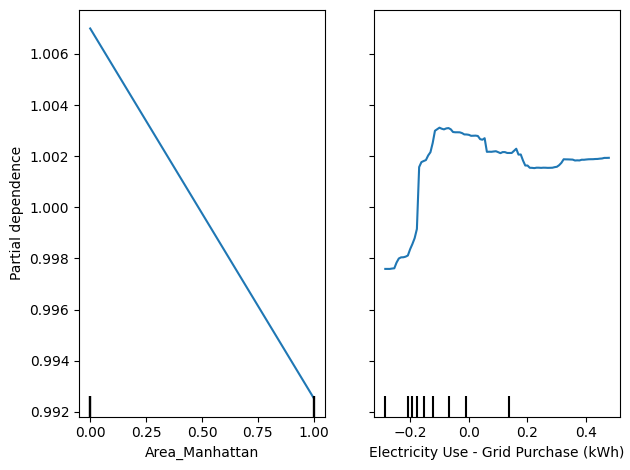

In [234]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Example: suppose you want to analyze the 0th and 1st features in your dataset
features_to_plot = ['Area_Manhattan', 
                    'Electricity Use - Grid Purchase (kWh)']  # can also be a list of column names if X is a DataFrame

# Generate the partial dependence plots
PartialDependenceDisplay.from_estimator(
    estimator=best_rf,
    X=X_train,
    features=features_to_plot,
    kind='average'
)

plt.tight_layout()
plt.show()


In [47]:
preds = best_rf.predict(X_train)

In [48]:
residuals = preds - y_train

In [67]:
df_test = pd.concat([merged_df[['Latitude','Longitude']], residuals],axis=1)

In [68]:
df_test.columns = [['Latitude','Longitude','residuals']]

In [69]:
df_test

,Latitude,Longitude,residuals
0,40.812315,-73.953428,-0.000765
1,40.835453,-73.927362,0.001767
2,40.790145,-73.969710,0.000604
3,40.804170,-73.919355,-0.000442
4,40.810912,-73.952470,-0.000818
...,...,...,...
11224,40.811363,-73.931140,-0.003210
11225,40.808727,-73.963248,0.000250
11226,40.809583,-73.959963,0.002252
11227,40.772385,-73.946858,-0.000089


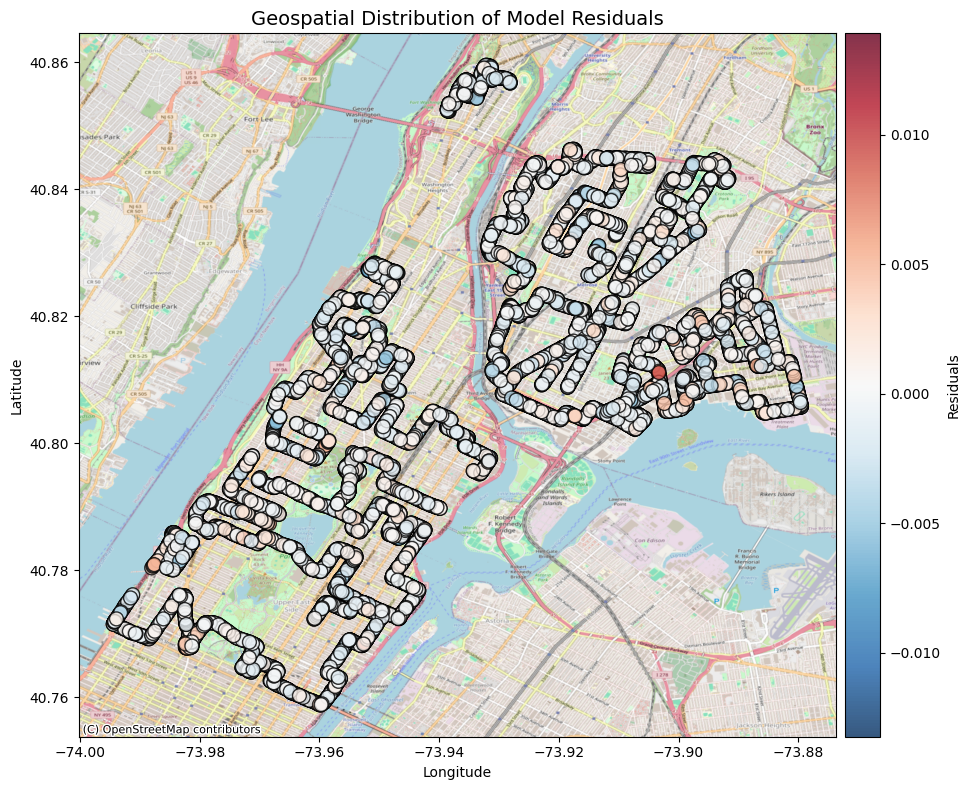

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.colors import Normalize
import numpy as np

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Create scatter plot with residuals as color
# Use a diverging colormap centered at 0
norm = Normalize(vmin=df_test['residuals'].min(), vmax=df_test['residuals'].max())
scatter = ax.scatter(
    df_test['Longitude'], 
    df_test['Latitude'],
    c=df_test['residuals'],
    cmap='RdBu_r',  # Red-Blue diverging colormap, reversed so positive is red
    norm=norm,
    alpha=0.8,
    s=100,  # Size of points
    edgecolor='black',
    zorder=3
)

# Add basemap
try:
    ctx.add_basemap(
        ax, 
        crs="EPSG:4326",  # WGS84 coordinate system
        source=ctx.providers.OpenStreetMap.Mapnik,
        zoom=14
    )
except:
    print("Could not add basemap. Contextily may not be installed or no internet connection.")
    # Set limit if basemap fails
    ax.set_xlim(df_test['Longitude'].min() - 0.01, df_test['Longitude'].max() + 0.01)
    ax.set_ylim(df_test['Latitude'].min() - 0.01, df_test['Latitude'].max() + 0.01)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.01)
cbar.set_label('Residuals')

# Add title and labels
plt.title('Geospatial Distribution of Model Residuals', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# If you want to save the figure
# plt.savefig('geospatial_residuals.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

# Alternative version using Folium (interactive)
try:
    import folium
    from folium.plugins import HeatMap
    
    # Create a folium map centered at mean coordinates
    center_lat = df_test['Latitude'].mean()
    center_lon = df_test['Longitude'].mean()
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=14)
    
    # Add points with color based on residuals
    # Find max absolute residual for scaling
    max_abs_residual = max(abs(df_test['residuals'].max()), abs(df_test['residuals'].min()))
    
    for idx, row in df_test.iterrows():
        # Determine color (red for positive, blue for negative)
        residual = row['residuals']
        if residual > 0:
            color = 'red'
            # Scale intensity based on magnitude relative to max
            intensity = int(255 * min(1, abs(residual)/max_abs_residual))
            fill_color = f'#{intensity:02x}0000'
        else:
            color = 'blue'
            # Scale intensity based on magnitude relative to max
            intensity = int(255 * min(1, abs(residual)/max_abs_residual))
            fill_color = f'#0000{intensity:02x}'
        
        # Add circle marker
        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=10,
            color=color,
            fill=True,
            fill_color=fill_color,
            fill_opacity=0.7,
            popup=f"Residual: {residual:.6f}"
        ).add_to(m)
    
    # Save to HTML file
    # m.save('residuals_map.html')
    
    # Display the map in a Jupyter notebook
    # display(m)
    
    print("Interactive Folium map created. Run in a Jupyter notebook to visualize.")
    
except ImportError:
    print("Folium not installed. Install with 'pip install folium' for interactive maps.")

In [25]:
shap_df = pd.concat([merged_df[['Latitude','Longitude']],X_train],axis=1)
shap_df.head()

,Latitude,Longitude,airtemp,relative humidity,avg wind speed,wind direction,solar flux,building_area_25,building_area_50,building_area_100,...,B08,B8A,B11,B12,Weather Normalized Site EUI (kBtu/ft²),Weather Normalized Site Energy Use (kBtu),Electricity Use - Grid Purchase (kWh),Natural Gas Use (kBtu),ENERGY STAR Score,Area_Manhattan
0,40.812315,-73.953428,-1.142219,0.683841,0.578307,0.814269,-1.531980,1.456394,1.057720,0.898824,...,2.457983,0.956565,1.990267,1.847867,0.245099,-0.294237,-0.151568,-0.225578,0.209808,True
1,40.835453,-73.927362,-0.510366,0.683841,-0.182716,0.238885,-0.463903,1.945507,0.783492,-0.193245,...,-0.642406,0.062987,1.416564,1.521532,0.656428,-0.081910,-0.164657,0.122308,-0.210480,False
2,40.790145,-73.969710,0.332104,-0.364639,1.034921,1.389653,-0.587575,0.796822,0.633919,0.423201,...,-1.011423,-0.704919,-0.364516,-0.228498,-0.189672,0.107281,0.100325,-0.021152,1.023872,True
3,40.804170,-73.919355,2.017044,-2.244672,-2.161376,-2.126582,0.587310,0.195098,0.126531,-0.712112,...,-0.864783,-0.223894,-0.050678,0.140479,-0.190757,-0.341121,-0.189861,-0.266080,-0.034646,False
4,40.810912,-73.952470,-0.720984,0.105369,0.426102,1.197858,0.851519,-0.167564,0.463721,1.249540,...,0.132691,-0.463106,0.503036,0.826219,0.729873,-0.208801,-0.008779,-0.235162,-0.145761,True


In [28]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import joblib

# Start timer to track execution time
start_time = time.time()

print("Starting SHAP analysis...")

# Load your model if not already loaded
# Uncomment this if needed
# best_rf = joblib.load('best_random_forest.pkl')

# Use a subset of data for faster analysis
sample_size = 100  # Using 100 samples for faster computation
if len(shap_df) > sample_size:
    sample_indices = np.random.choice(len(shap_df), size=sample_size, replace=False)
    analysis_df = X_train.iloc[sample_indices]
    print(f"Using {sample_size} samples out of {len(shap_df)} for SHAP analysis")
else:
    analysis_df = X_train
    print(f"Using all {len(shap_df)} samples for SHAP analysis")

# Create the explainer - using newer SHAP API format that works with all versions
print("Creating SHAP explainer...")
# Directly create the explainer without modifying any attributes
explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values with progress tracking
print("Calculating SHAP values (this may take a few minutes)...")
shap_values = explainer(analysis_df)

# Report time taken for SHAP calculation
calc_time = time.time() - start_time
print(f"SHAP values calculated in {calc_time:.2f} seconds")

# Create only the most informative plots
print("Generating plots...")

# 1. Feature Importance Summary (beeswarm plot)
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, show=False, max_display=15)  # Limit to top 15 features
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Beeswarm plot saved")

# 2. Bar plot (faster alternative to summary plot)
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, show=False, max_display=15)  # Limit to top 15 features
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Feature importance plot saved")

# 3. Waterfall plot for a single instance (very informative)
plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_values[0], show=False, max_display=15)  # First instance
plt.tight_layout()
plt.savefig('shap_waterfall_plot.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Waterfall plot saved")

# 4. Dependence plots for just the top 3 features (faster)
# Get feature importance to identify top features
feature_names = shap_values.feature_names
feature_importance = np.abs(shap_values.values).mean(0)
top_indices = np.argsort(-feature_importance)[:3]  # Only top 3
top_features = [feature_names[i] for i in top_indices]

for i, feature in enumerate(top_features):
    plt.figure(figsize=(8, 6))
    shap.plots.scatter(shap_values[:, feature], show=False)
    plt.tight_layout()
    plt.savefig(f'shap_dependence_{feature}.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ Dependence plot for {feature} saved")

# Total time taken
total_time = time.time() - start_time
print(f"\nTotal execution time: {total_time:.2f} seconds")
print(f"SHAP analysis complete! Plots saved to current directory.")

Starting SHAP analysis...
Using 100 samples out of 11229 for SHAP analysis
Creating SHAP explainer...
Calculating SHAP values (this may take a few minutes)...
SHAP values calculated in 140.31 seconds
Generating plots...
✓ Beeswarm plot saved
✓ Feature importance plot saved
✓ Waterfall plot saved
✓ Dependence plot for Area_Manhattan saved
✓ Dependence plot for B01 saved
✓ Dependence plot for Electricity Use - Grid Purchase (kWh) saved

Total execution time: 141.41 seconds
SHAP analysis complete! Plots saved to current directory.
